# Gaussian-corruption peakfinder survival by DM reach

This focused notebook compares the number of final `float16` pixels at or above threshold with the number of raw candidates surviving the production full-band bowtie peakfinder for `dm_reach = 1, 2, 4, 8, 16, 32`. Counts are totals across all 60 beams. Faint points are individual paired Monte Carlo trials; coloured lines are medians at each corruption percentage; the dashed line is the no-suppression reference.

By default, campaigns are read from `peakfinder_tests/results_gaussian_corruption_dm_reach/dm_reach_<N>`. The existing `peakfinder_tests/results_gaussian_corruption_timing` campaign is accepted as the `dm_reach=8` member when it is compatible. Set `PIRATE_GAUSSIAN_DM_REACH_RESULTS_ROOT` to use a different parent directory. The loader validates campaign signatures after removing only `dm_reach`, then verifies the trial seeds, Gaussian summaries, calibrated maps and injected-pixel counts are identical across reaches.

Generate or resume a compact six-reach comparison campaign from the repository root with: `for dm in 1 2 4 8 16 32; do python -m peakfinder_tests.benchmark_gaussian_corruption_timing --config configs/dedispersion/chord_sb2_et.yml --results-dir peakfinder_tests/results_gaussian_corruption_dm_reach/dm_reach_${dm} --total-beams 60 --beam-batch-size 60 --trials 5 --corruption-percentages 0.001 0.003 0.01 0.03 0.1 0.3 1.0 2.0 --threshold 10 --dm-reach ${dm} --waist-bins 1 --device 0 --base-seed 20260825 --resume; done`. Use the same trial count and percentage grid for every reach.

In [1]:
import csv
import hashlib
import json
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import yaml

DM_REACH_GRID = (1, 2, 4, 8, 16, 32)
EXPECTED_SHAPES = (
    (4096, 128), (1024, 64), (2048, 64), (1024, 64),
    (1024, 32), (2048, 32), (512, 32), (1024, 32),
    (1024, 16), (2048, 16),
)
PIXELS_PER_BEAM = 983_040
TOTAL_BEAMS = 60
REQUIRED_TRIAL_FIELDS = {
    'schema_version', 'campaign_id', 'trial', 'seed', 'total_beams',
    'beam_batch_size', 'threshold', 'method', 'dm_reach', 'waist_bins',
    'target_corruption_percent', 'achieved_corruption_percent',
    'target_pixels_above_threshold', 'achieved_pixels_above_threshold',
    'pixel_count_error', 'max_abs_beam_pixel_count_error',
    'per_beam_calibration_json', 'total_gaussians',
    'total_pixels_above_threshold', 'total_peakfinder_candidates',
    'peakfinder_survival_fraction', 'total_decoded_candidates', 'status',
}
PAIRED_WORKLOAD_FIELDS = (
    'seed', 'target_corruption_percent', 'achieved_corruption_percent',
    'target_pixels_above_threshold', 'achieved_pixels_above_threshold',
    'pixel_count_error', 'max_abs_beam_pixel_count_error',
    'per_beam_calibration_json', 'total_gaussians',
    'gaussians_per_beam_min', 'gaussians_per_beam_median',
    'gaussians_per_beam_max', 'gaussian_dm_width_bins_min',
    'gaussian_dm_width_bins_median', 'gaussian_dm_width_bins_max',
    'gaussian_time_width_bins_min', 'gaussian_time_width_bins_median',
    'gaussian_time_width_bins_max', 'gaussian_correlation_min',
    'gaussian_correlation_median', 'gaussian_correlation_max',
    'gaussian_relative_amplitude_min',
    'gaussian_relative_amplitude_median',
    'gaussian_relative_amplitude_max', 'total_pixels_above_threshold',
)

def repository_root():
    configured = os.environ.get('PIRATE_REPOSITORY_ROOT')
    starts = [Path(configured).expanduser()] if configured else [Path.cwd()]
    for start in starts:
        for candidate in (start.resolve(), *start.resolve().parents):
            if (candidate / 'peakfinder_tests' / 'benchmark_gaussian_corruption_timing.py').is_file():
                return candidate
    raise FileNotFoundError(
        'cannot locate the PIRATE repository; set PIRATE_REPOSITORY_ROOT'
    )

REPOSITORY_ROOT = repository_root()
configured_root = os.environ.get('PIRATE_GAUSSIAN_DM_REACH_RESULTS_ROOT')
RESULTS_ROOT = (
    Path(configured_root).expanduser().resolve()
    if configured_root else
    REPOSITORY_ROOT / 'peakfinder_tests' / 'results_gaussian_corruption_dm_reach'
)

def read_csv_strict(path):
    with path.open(newline='') as stream:
        reader = csv.DictReader(stream)
        fields = tuple(reader.fieldnames or ())
        if not fields or len(fields) != len(set(fields)):
            raise ValueError(f'{path}: missing or duplicate CSV columns')
        rows = list(reader)
    if not rows:
        raise ValueError(f'{path}: table is empty')
    return fields, rows

def campaign_directory(dm_reach):
    candidates = [
        RESULTS_ROOT / f'dm_reach_{dm_reach}',
        REPOSITORY_ROOT / 'peakfinder_tests' /
        f'results_gaussian_corruption_timing_dm_reach_{dm_reach}',
    ]
    if dm_reach == 8:
        candidates.append(
            REPOSITORY_ROOT / 'peakfinder_tests' /
            'results_gaussian_corruption_timing'
        )
    for candidate in candidates:
        if all((candidate / name).is_file() for name in (
            'trials.csv', 'summary.csv', 'metadata.yaml',
        )):
            return candidate
    expected = ', '.join(str(path) for path in candidates)
    raise FileNotFoundError(
        f'missing dm_reach={dm_reach} campaign; checked: {expected}'
    )

def load_campaign(dm_reach):
    directory = campaign_directory(dm_reach)
    fields, rows = read_csv_strict(directory / 'trials.csv')
    read_csv_strict(directory / 'summary.csv')
    if not REQUIRED_TRIAL_FIELDS <= set(fields):
        missing = sorted(REQUIRED_TRIAL_FIELDS - set(fields))
        raise ValueError(f'{directory}/trials.csv: missing columns {missing}')
    with (directory / 'metadata.yaml').open() as stream:
        metadata = yaml.safe_load(stream) or {}
    if metadata.get('schema_name') != 'pirate-gaussian-corruption-timing':
        raise ValueError(f'{directory}: unexpected metadata schema')
    payload = metadata.get('campaign_signature_payload')
    signature = metadata.get('campaign_signature')
    if not isinstance(payload, dict) or not isinstance(signature, str):
        raise ValueError(f'{directory}: invalid campaign signature metadata')
    computed = hashlib.sha256(
        json.dumps(
            payload, sort_keys=True, separators=(',', ':'),
            ensure_ascii=True,
        ).encode('utf-8')
    ).hexdigest()
    if computed != signature:
        raise ValueError(f'{directory}: campaign signature mismatch')
    if int(payload.get('dm_reach', -1)) != dm_reach:
        raise ValueError(f'{directory}: signature has the wrong dm_reach')
    if int(metadata['peakfinder']['dm_reach']) != dm_reach:
        raise ValueError(f'{directory}: peakfinder metadata has the wrong dm_reach')
    campaign = metadata['campaign']
    plan = metadata['plan']
    if metadata['campaign_completeness'].get('complete') is not True:
        raise ValueError(f'{directory}: campaign is incomplete')
    if tuple(tuple(map(int, shape)) for shape in plan['tree_shapes_ndm_ntime']) != EXPECTED_SHAPES:
        raise ValueError(f'{directory}: plan shapes changed')
    if int(plan['pixels_per_beam']) != PIXELS_PER_BEAM:
        raise ValueError(f'{directory}: pixels_per_beam changed')
    config_document = plan['config_document']
    expected_duration = (
        float(config_document['time_sample_ms'])
        * int(config_document['time_samples_per_chunk'])
    )
    if not np.isclose(
        float(plan['chunk_duration_ms']), expected_duration,
        rtol=1e-12, atol=1e-12,
    ):
        raise ValueError(f'{directory}: chunk duration is inconsistent')
    if int(campaign['total_beams']) != TOTAL_BEAMS:
        raise ValueError(f'{directory}: campaign does not contain 60 beams')
    if int(campaign['total_pixels_per_trial']) != TOTAL_BEAMS * PIXELS_PER_BEAM:
        raise ValueError(f'{directory}: total pixel count is inconsistent')
    campaign_id = metadata['campaign_id']
    trial_count = int(campaign['trials'])
    targets = tuple(float(value) for value in campaign['percentage_grid'])
    by_key = {}
    valid_rows = []
    for line_number, row in enumerate(rows, start=2):
        context = f'{directory}/trials.csv:{line_number}'
        if row['campaign_id'] != campaign_id or int(row['dm_reach']) != dm_reach:
            raise ValueError(f'{context}: campaign or dm_reach mismatch')
        if int(row['total_beams']) != TOTAL_BEAMS:
            raise ValueError(f'{context}: total_beams mismatch')
        key = (int(row['trial']), float(row['target_corruption_percent']))
        if key in by_key:
            raise ValueError(f'{context}: duplicate trial/target key {key}')
        by_key[key] = row
        if row['status'].startswith('failed_'):
            continue
        injected = int(row['total_pixels_above_threshold'])
        survived = int(row['total_peakfinder_candidates'])
        decoded = int(row['total_decoded_candidates'])
        if not 0 <= survived <= injected or decoded != survived:
            raise ValueError(f'{context}: inconsistent candidate counts')
        expected_survival = survived / injected if injected else 0.0
        if not np.isclose(
            float(row['peakfinder_survival_fraction']), expected_survival,
            rtol=1e-10, atol=1e-12,
        ):
            raise ValueError(f'{context}: inconsistent survival fraction')
        valid_rows.append(row)
    expected_keys = {
        (trial, target) for trial in range(trial_count) for target in targets
    }
    if set(by_key) != expected_keys:
        raise ValueError(f'{directory}: incomplete trial/target grid')
    if not valid_rows:
        raise ValueError(f'{directory}: no valid peakfinder rows')
    return {
        'directory': directory, 'metadata': metadata, 'payload': payload,
        'rows': rows, 'valid_rows': valid_rows, 'by_key': by_key,
        'targets': targets,
    }

campaigns = {dm_reach: load_campaign(dm_reach) for dm_reach in DM_REACH_GRID}
for dm_reach, campaign_data in campaigns.items():
    print(f'dm_reach={dm_reach:2d}: {campaign_data["directory"]}')

dm_reach= 1: /home/mtrudu/src/pirate-updated/peakfinder_tests/results_gaussian_corruption_dm_reach/dm_reach_1
dm_reach= 2: /home/mtrudu/src/pirate-updated/peakfinder_tests/results_gaussian_corruption_dm_reach/dm_reach_2
dm_reach= 4: /home/mtrudu/src/pirate-updated/peakfinder_tests/results_gaussian_corruption_dm_reach/dm_reach_4
dm_reach= 8: /home/mtrudu/src/pirate-updated/peakfinder_tests/results_gaussian_corruption_dm_reach/dm_reach_8
dm_reach=16: /home/mtrudu/src/pirate-updated/peakfinder_tests/results_gaussian_corruption_dm_reach/dm_reach_16
dm_reach=32: /home/mtrudu/src/pirate-updated/peakfinder_tests/results_gaussian_corruption_dm_reach/dm_reach_32


In [2]:
def normalized_signature_payload(payload):
    normalized = json.loads(json.dumps(payload, sort_keys=True))
    normalized.pop('dm_reach', None)
    return normalized

reference_reach = DM_REACH_GRID[0]
reference = campaigns[reference_reach]
reference_payload = normalized_signature_payload(reference['payload'])
reference_keys = set(reference['by_key'])
for dm_reach in DM_REACH_GRID[1:]:
    observed = campaigns[dm_reach]
    if normalized_signature_payload(observed['payload']) != reference_payload:
        raise ValueError(
            f'dm_reach={dm_reach} campaign differs from dm_reach='
            f'{reference_reach} in fields other than dm_reach'
        )
    if set(observed['by_key']) != reference_keys:
        raise ValueError(f'dm_reach={dm_reach}: trial/target grid is not paired')
    for key in sorted(reference_keys):
        expected_row = reference['by_key'][key]
        observed_row = observed['by_key'][key]
        expected_failed = expected_row['status'].startswith('failed_')
        observed_failed = observed_row['status'].startswith('failed_')
        if expected_failed != observed_failed:
            raise ValueError(
                f'dm_reach={dm_reach}, key={key}: morphology success differs'
            )
        for field in PAIRED_WORKLOAD_FIELDS:
            if observed_row[field] != expected_row[field]:
                raise ValueError(
                    f'dm_reach={dm_reach}, key={key}: unpaired {field}'
                )
print(
    f'Validated six paired campaigns: {len(reference_keys)} configurations '
    f'per dm_reach, {TOTAL_BEAMS} beams per configuration.'
)

Validated six paired campaigns: 40 configurations per dm_reach, 60 beams per configuration.


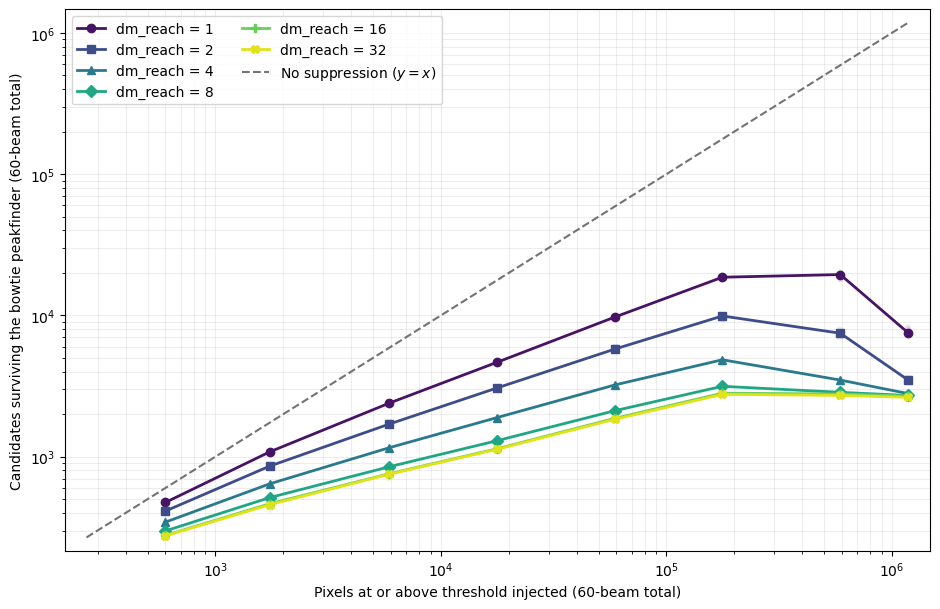

In [3]:
# Injected above-threshold pixels versus bowtie survivors by DM reach
colours = plt.cm.viridis(np.linspace(0.05, 0.95, len(DM_REACH_GRID)))
markers = ('o', 's', '^', 'D', 'P', 'X')
all_positive_counts = []
fig, ax = plt.subplots(figsize=(9.5, 6.2))

for colour, marker, dm_reach in zip(colours, markers, DM_REACH_GRID):
    rows = campaigns[dm_reach]['valid_rows']
    raw = np.asarray([
        (float(row['total_pixels_above_threshold']),
         float(row['total_peakfinder_candidates']))
        for row in rows
        if float(row['total_pixels_above_threshold']) > 0
        and float(row['total_peakfinder_candidates']) > 0
    ], dtype=float)
    if raw.size == 0:
        raise ValueError(f'dm_reach={dm_reach}: no positive count pairs')
    injected, survived = raw.T
    all_positive_counts.extend((injected, survived))
    ax.scatter(
        injected, survived, s=18, alpha=0.10, color=colour,
        marker=marker, edgecolors='none',
    )
    medians = []
    for target in sorted(campaigns[dm_reach]['targets']):
        selected = [
            row for row in rows
            if np.isclose(
                float(row['target_corruption_percent']), target,
                rtol=0, atol=1e-12,
            )
            and float(row['total_pixels_above_threshold']) > 0
            and float(row['total_peakfinder_candidates']) > 0
        ]
        if selected:
            medians.append((
                np.median([float(row['total_pixels_above_threshold']) for row in selected]),
                np.median([float(row['total_peakfinder_candidates']) for row in selected]),
            ))
    median_injected, median_survived = np.asarray(medians, dtype=float).T
    ax.plot(
        median_injected, median_survived, color=colour, marker=marker,
        linewidth=2.0, markersize=6, label=f'dm_reach = {dm_reach}',
    )

plot_min = min(float(values.min()) for values in all_positive_counts)
plot_max = max(float(values.max()) for values in all_positive_counts)
ax.plot(
    [plot_min, plot_max], [plot_min, plot_max], color='0.45',
    linestyle='--', linewidth=1.5, label='No suppression ($y=x$)',
)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(0.8 * plot_min, 1.25 * plot_max)
ax.set_ylim(0.8 * plot_min, 1.25 * plot_max)
ax.set_xlabel('Pixels at or above threshold injected (60-beam total)')
ax.set_ylabel('Candidates surviving the bowtie peakfinder (60-beam total)')
ax.grid(True, which='both', alpha=0.22)
ax.legend(loc='best', ncol=2)
fig.tight_layout()
plt.show()